<a href="https://colab.research.google.com/github/sammatiphugate/sammatiphugate/blob/main/Time_Series_Forecasting_with_RNN_Copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Time Series Forecasting with RNN: AirPassengers Dataset

# AIRLINE PASSENGER (TIME SERIES) PREDICTION USING LSTM

We will use Airline Passenger dataset for this project. This dataset provides monthly totals of a US airline passengers from 1949 to 1960. You can download the dataset from Kaggle link below:
https://www.kaggle.com/chirag19/air-passengers

We will use LSTM deep learning model for this project. The Long Short-Term Memory network, or LSTM network, is a recurrent neural network that is trained using Backpropagation through time and overcomes the vanishing gradient problem. LSTM can be used to create large recurrent networks that in turn can be used to address difficult sequence problems in machine learning and achieve state-of-the-art results. Instead of neurons, LSTM networks have memory blocks that are connected through layers.

#### Aim of the project:

Given the number of passengers (in units of thousands) for last two months, what is the number of passengers next month? In order to solve this problem we will build a LSTM model and train this model with our train data which is first 100 months in our dataset. After the LSTM model training finishes and learn the pattern in time series train data, we will ask it the above question  question and get the answer from it.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.layers import Dropout

In [ ]:
# Load dataset
data = pd.read_csv('AirPassengers.csv')  # Replace with the correct path to your dataset
data['Month'] = pd.to_datetime(data['Month'])  # Convert 'Month' column to datetime format
data.set_index('Month', inplace=True)  # Set 'Month' as the index for the dataframe

In [ ]:
# Preprocess data
scaler = MinMaxScaler(feature_range=(0, 1))  # Initialize scaler to normalize data between 0 and 1
data_scaled = scaler.fit_transform(data[['#Passengers']])  # Scale the '#Passengers' column

#Check how the data is changing
print("Actual Data:\n", data['#Passengers'][:5])
print(type(data_scaled))
print("Transformed data after MinMaxScaler:\n",data_scaled[:13])

Actual Data:
 Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Name: #Passengers, dtype: int64
<class 'numpy.ndarray'>
Transformed data after MinMaxScaler:
 [[0.01544402]
 [0.02702703]
 [0.05405405]
 [0.04826255]
 [0.03281853]
 [0.05984556]
 [0.08494208]
 [0.08494208]
 [0.06177606]
 [0.02895753]
 [0.        ]
 [0.02702703]
 [0.02123552]]


In [ ]:
# Create sequences for the RNN
def create_dataset(data, time_steps=12):
    """
    Function to create input-output sequences for training/testing the RNN.
    :param data: Scaled time-series data
    :param time_steps: Number of time steps (lags) to use for each sequence
    :return: Arrays for features (X) and target variable (y)
    """
    X, y = [], []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps, 0])  # Extract 'time_steps=12' data points as features
        y.append(data[i + time_steps, 0])  # The next data point is the target

        # Optional: Print last sequence added to X and y for debugging
        #print("Last sequence added to X:", X[-1]) #list[-1]: Refers to the last element.
        #print("Last value added to y:", y[-1])
    return np.array(X), np.array(y)

time_steps = 12  # Number of months to use for prediction
X, y = create_dataset(data_scaled, time_steps)  # Create input-output sequences
print("Value of X after create_dataset() but before reshape:\n",X[0:1])
print("Value of y after create_dataset() but before reshape:\n", y[0:1])

Value of X after create_dataset() but before reshape:
 [[0.01544402 0.02702703 0.05405405 0.04826255 0.03281853 0.05984556
  0.08494208 0.08494208 0.06177606 0.02895753 0.         0.02702703]]
Value of y after create_dataset() but before reshape:
 [0.02123552]


In [ ]:
#X.shape[0]: This represents the number of samples in X (the first dimension).
#time_steps: This is a variable that likely represents the number of time steps in your sequence data.
#1: This sets the number of features for each time step.
print(X.shape[0])
X = X.reshape((X.shape[0], time_steps, 1))  # Reshape for LSTM input (samples, time_steps, features)
print("Value of X after:",X[0:1])
#print("Value of y:",y)

132
Value of X after: [[[0.01544402]
  [0.02702703]
  [0.05405405]
  [0.04826255]
  [0.03281853]
  [0.05984556]
  [0.08494208]
  [0.08494208]
  [0.06177606]
  [0.02895753]
  [0.        ]
  [0.02702703]]]


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define hyperparameter grid

In [ ]:
# Install required packages if needed
# pip install scikeras tensorflow scikit-learn
#!pip install scikeras scikit-learn
#!pip install --upgrade scikit-learn

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras import Input
from tensorflow.keras.layers import LSTM, Dropout, Dense
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import GridSearchCV

# Define your input shape globally or pass it dynamically
time_steps = X_train.shape[1]  # assuming X_train is already defined

def build_model(units=64, dropout_rate=0.2, optimizer='adam'):
    model = Sequential()
    model.add(Input(shape=(time_steps, 1)))  # Explicit Input layer
    model.add(LSTM(units, activation='relu', return_sequences=True))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model


# Wrap the model using SciKeras
model = KerasRegressor(
    model=build_model,
    verbose=0
)

# Define hyperparameter grid
#model__units	Number of LSTM units in the first layer (64 or 128)
#model__dropout_rate	Dropout rate to prevent overfitting (0.2 or 0.5)
#model__optimizer	Optimizer used for training (adam or rmsprop)
#batch_size	Number of samples per gradient update (16 or 32)
#epochs	Number of training iterations over the full dataset (25 or 50)
param_grid = {
    'model__units': [64, 128],
    'model__dropout_rate': [0.2, 0.5],
    'model__optimizer': ['adam', 'rmsprop'],
    'batch_size': [16, 32],
    'epochs': [25, 50]
}

# Run GridSearchCV
grid = GridSearchCV(estimator=model, param_grid=param_grid, cv=3)
model = grid.fit(X_train, y_train)

# Output best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)


Best Parameters: {'batch_size': 16, 'epochs': 50, 'model__dropout_rate': 0.2, 'model__optimizer': 'adam', 'model__units': 128}
Best Score: 0.909199767529168


In [ ]:
# Make predictions
predictions = model.predict(X_test)  # Predict on test data
#predictions.reshape(-1, 1): flattens the array into a 1D
#The -1 tells NumPy to infer the number of rows automatically based on the original array's size.
#The 1 means you want 1 column.
predicted_prices = scaler.inverse_transform(predictions.reshape(-1, 1))  # Reverse scaling for predictions
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))  # Reverse scaling for actual values

print("Predicted No of Passengers after Reverse scaling:\n", predicted_prices[0:5])
print("Actual No of Passengers after Reverse scaling:\n", actual_prices[0:5])

Predicted price after Reverse scaling:
 [[221.62515]
 [306.15103]
 [158.75906]
 [181.55101]
 [308.32742]]
Actual price after Reverse scaling:
 [[259.]
 [306.]
 [199.]
 [242.]
 [318.]]


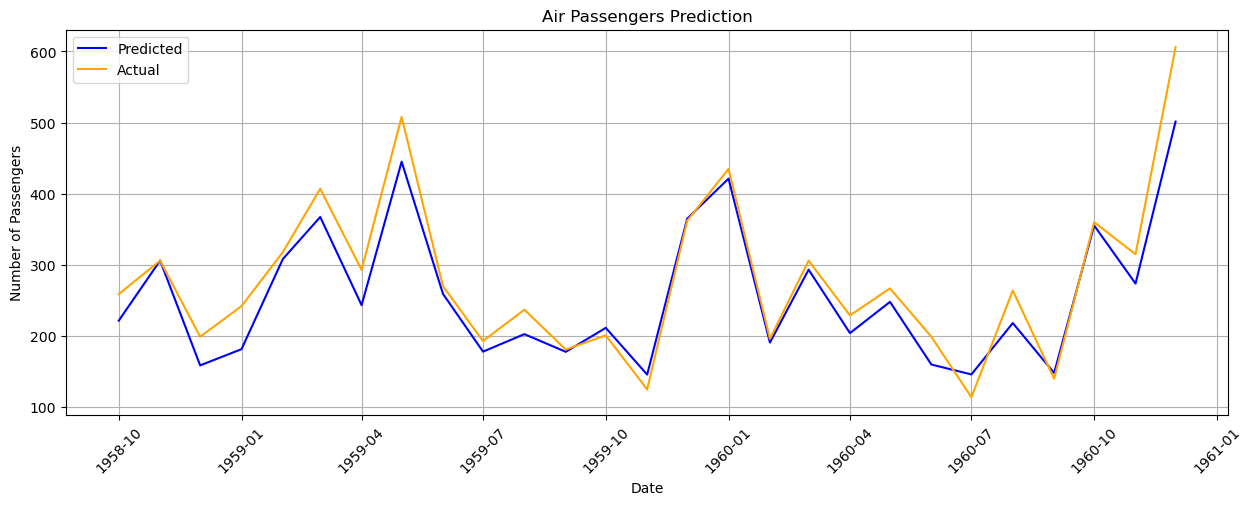

In [ ]:
# Plot results with dates on the x-axis
plt.figure(figsize=(15, 5))  # Set figure size
#data.index[-len(predicted_prices):] → Uses negative indexing to select the last len(predicted_prices) elements from the index.
plt.plot(data.index[-len(predicted_prices):], predicted_prices, label='Predicted', color='blue')  # Predicted values
plt.plot(data.index[-len(actual_prices):], actual_prices, label='Actual', color='orange')  # Actual values
plt.title('Air Passengers Prediction')  # Title of the plot
plt.xlabel('Date')  # X-axis label
plt.ylabel('Number of Passengers')  # Y-axis label
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend()  # Add legend
plt.grid(True)  # Add grid lines for clarity
plt.show()  # Display the plot

### Well Done!